In [1]:
#read the dataset
import json
import pandas as pd

file_path = r"F:\ERP_data\final_corpusRCRS_clean.jsonl"
data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

In [2]:
counts = df['source_type'].value_counts()
print(counts)

source_type
comment       1930
submission     474
Name: count, dtype: int64


In [3]:
df['text_for_analysis'].head()

0    Most males don't want to be nurses, because mo...
1    What are you talking about? Professors get pai...
2    Not all. A couple of the women I work with (in...
3    Bitch I went from a U to a grade 5 in a month ...
4    Here's something a lot of people don't know: i...
Name: text_for_analysis, dtype: object

In [4]:
#1.set up topic modelling text
#delete the empty text
df_topic = df[
    df['text_for_analysis'].notna()
].copy()

df_topic = df_topic[
    df_topic['text_for_analysis'].str.strip() != ""
]

len(df_topic)

2404

In [5]:
# set up documents
documents = df_topic[
    'text_for_analysis'
].tolist()
documents[:3]

["Most males don't want to be nurses, because most of them would rather be doctors. The ones that do become nurses don't complain because there are still male doctors around, so it isn't like hospitals are completely dominated by women. STEM companies on the other hand, are completely dominated by men. Women deserve to be celebrated because of their underrepresentation. Just like how we have Black History Month. Which essentially celebrates a minority group that was suppressed and underrepresented for so many years. Men don't need to be celebrated because we've been given so many advantages through the years. I think it's time we get everyone on the same level. Which starts with lifting women up to believe that they are as equal as men, if not better.",
 'What are you talking about? Professors get paid much more than teachers. I’m not sure where you live but where I’m from professors get paid almost double the wage that teachers do.\n\nI’m not sure what you mean by the vets and account

In [6]:
# 2. text pre-processing
!pip install nltk gensim pyLDAvis

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', download_dir='D:/nltk_data')
nltk.download('wordnet', download_dir='D:/nltk_data')

nltk.data.path.append('D:/nltk_data')


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: D:\Scripts\python.exe -m pip install --upgrade pip


NameError: name 'nltk' is not defined

In [8]:
# create functions
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    # remove URLs
    text = re.sub(
        r'http\S+|www\S+',
        '',
        text
    )

    # keep only words
    text = re.sub(
        r'[^a-z\s]',
        ' ',
        text
    )

    words = text.split()


    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word)>2
    ]

    return words

In [9]:
processed_docs = [
    preprocess(doc)
    for doc in documents
]

processed_docs[:2]

[['male',
  'want',
  'nurse',
  'would',
  'rather',
  'doctor',
  'one',
  'become',
  'nurse',
  'complain',
  'still',
  'male',
  'doctor',
  'around',
  'like',
  'hospital',
  'completely',
  'dominated',
  'woman',
  'stem',
  'company',
  'hand',
  'completely',
  'dominated',
  'men',
  'woman',
  'deserve',
  'celebrated',
  'underrepresentation',
  'like',
  'black',
  'history',
  'month',
  'essentially',
  'celebrates',
  'minority',
  'group',
  'suppressed',
  'underrepresented',
  'many',
  'year',
  'men',
  'need',
  'celebrated',
  'given',
  'many',
  'advantage',
  'year',
  'think',
  'time',
  'get',
  'everyone',
  'level',
  'start',
  'lifting',
  'woman',
  'believe',
  'equal',
  'men',
  'better'],
 ['talking',
  'professor',
  'get',
  'paid',
  'much',
  'teacher',
  'sure',
  'live',
  'professor',
  'get',
  'paid',
  'almost',
  'double',
  'wage',
  'teacher',
  'sure',
  'mean',
  'vet',
  'accountant',
  'since',
  'gender',
  'ratio',
  'pretty',

In [10]:
import sys

In [11]:
# 3.LDA model
from gensim import corpora
dictionary = corpora.Dictionary(
    processed_docs
)
dictionary.filter_extremes(
    no_below=5,
    no_above=0.5
)
len(dictionary)

3014

In [12]:
corpus = [
    dictionary.doc2bow(text)
    for text in processed_docs
]
corpus[:2]

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 2),
  (7, 1),
  (8, 1),
  (9, 2),
  (10, 1),
  (11, 2),
  (12, 2),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 1),
  (24, 2),
  (25, 2),
  (26, 2),
  (27, 3),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 2),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 2)],
 [(2, 1),
  (12, 1),
  (13, 1),
  (15, 1),
  (16, 2),
  (24, 4),
  (25, 2),
  (26, 1),
  (27, 6),
  (30, 1),
  (32, 1),
  (33, 2),
  (35, 2),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 2),
  (56, 1),
  (57, 1),
  (58, 1),
  (59, 3),
  (60, 2),
  (61, 1),
  (62, 1),
  (63, 1),
  (64, 7),
  (65, 3),
  (66, 1),
  (67, 1),
  (68, 2),
  (69, 2),
  (70, 1),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 2),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1)

In [13]:
# 4. choose number of LDA topics
from gensim.models import LdaModel
from gensim.models import CoherenceModel

topic_range = range(3,16)
coherence_scores=[]

for k in topic_range:

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=10,
        random_state=42
    )

    coherence = CoherenceModel(
        model=lda,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_scores.append(
        coherence.get_coherence()
    )

coherence_scores

[np.float64(0.35521350547336983),
 np.float64(0.4073835870613945),
 np.float64(0.40132603678909884),
 np.float64(0.4141009305575311),
 np.float64(0.4281949484237787),
 np.float64(0.4301768556583276),
 np.float64(0.39226402240159164),
 np.float64(0.42142259724445186),
 np.float64(0.40148636786849234),
 np.float64(0.4051983451239268),
 np.float64(0.4032610002028398),
 np.float64(0.40627569991279644),
 np.float64(0.4209008638014957)]

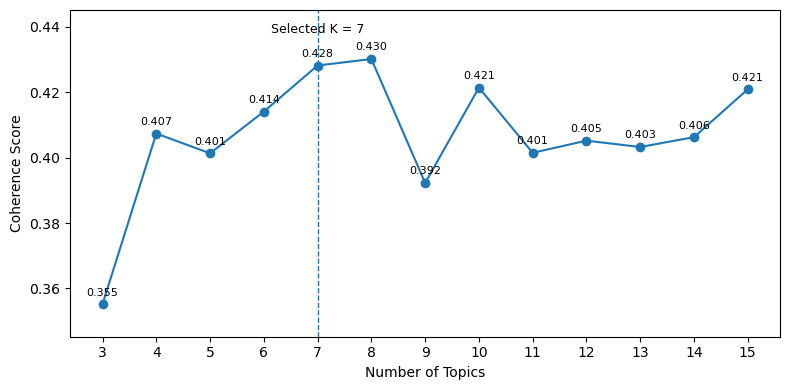

In [17]:
# plot: the highest point
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

x_values = list(topic_range)

plt.plot(
    x_values,
    coherence_scores,
    marker='o'
)

for x, y in zip(x_values, coherence_scores):
    plt.text(
        x,
        y + 0.002,
        f"{y:.3f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.axvline(
    x=7,
    linestyle='--',
    linewidth=1
)

plt.text(
    7,
    max(coherence_scores) + 0.008,
    "Selected K = 7",
    ha='center',
    fontsize=9
)

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")

plt.xticks(x_values)

plt.ylim(
    min(coherence_scores) - 0.01,
    max(coherence_scores) + 0.015
)

plt.tight_layout()
plt.show()

In [19]:
# test Topic num
for k in [6,7,8,10]:

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=20,
        random_state=42
    )

    print("\n================")
    print("TOPIC NUMBER:", k)

    for idx, topic in lda.show_topics(
        num_topics=k,
        num_words=10,
        formatted=False
    ):
        print(
            idx,
            [word for word,prob in topic]
        )


TOPIC NUMBER: 6
0 ['like', 'job', 'would', 'work', 'want', 'feel', 'get', 'engineering', 'major', 'really']
1 ['men', 'female', 'like', 'get', 'male', 'less', 'microsoft', 'also', 'look', 'gender']
2 ['men', 'field', 'gender', 'people', 'male', 'think', 'like', 'would', 'job', 'female']
3 ['female', 'scientist', 'one', 'like', 'work', 'male', 'team', 'think', 'get', 'people']
4 ['girl', 'engineering', 'school', 'tech', 'program', 'science', 'interested', 'coding', 'gender', 'summer']
5 ['bouman', 'black', 'hole', 'katie', 'algorithm', 'data', 'team', 'image', 'people', 'work']

TOPIC NUMBER: 7
0 ['like', 'engineering', 'would', 'major', 'college', 'science', 'program', 'student', 'want', 'job']
1 ['men', 'female', 'like', 'get', 'male', 'need', 'also', 'man', 'look', 'less']
2 ['men', 'field', 'gender', 'people', 'male', 'think', 'thing', 'like', 'female', 'would']
3 ['female', 'one', 'work', 'like', 'scientist', 'field', 'get', 'think', 'young', 'want']
4 ['girl', 'engineering', 'sch

In [20]:
# 5. train k=7
from gensim.models import LdaModel

best_k = 7

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    passes=20,
    random_state=42
)

In [21]:
# Check final LDA model settings
print("num_topics:", lda_model.num_topics)
print("passes used in final training: 20")
print("random_state: 42")
print("alpha:", lda_model.alpha)
print("eta:", lda_model.eta)
print("minimum_probability:", lda_model.minimum_probability)

num_topics: 7
passes used in final training: 20
random_state: 42
alpha: [0.14285715 0.14285715 0.14285715 0.14285715 0.14285715 0.14285715
 0.14285715]
eta: [0.14285715 0.14285715 0.14285715 ... 0.14285715 0.14285715 0.14285715]
minimum_probability: 0.01


In [10]:
# calculate p for each topic
document_topics = []

for bow in corpus:
    
    topic_prob = lda_model.get_document_topics(
        bow
    )
    
    # the topic with the highest p
    dominant_topic = max(
        topic_prob,
        key=lambda x:x[1]
    )[0]
    
    dominant_prob = max(
        topic_prob,
        key=lambda x:x[1]
    )[1]
       
    document_topics.append(
        (dominant_topic, dominant_prob)
    )

In [12]:
df_topic['topic'] = [
    x[0] for x in document_topics
]

df_topic['topic_probability'] = [
    x[1] for x in document_topics
]

df_topic[
    ['topic',
     'topic_probability',
     'text_for_analysis']
].head()

,topic,topic_probability,text_for_analysis
0,2,0.876848,"Most males don't want to be nurses, because mo..."
1,2,0.644316,What are you talking about? Professors get pai...
2,3,0.594745,Not all. A couple of the women I work with (in...
3,2,0.512195,Bitch I went from a U to a grade 5 in a month ...
4,2,0.682517,Here's something a lot of people don't know: i...


In [14]:
# example ducuments for each topic
for topic_id in range(7):

    print("\n====================")
    print("TOPIC", topic_id)

    examples = (
        df_topic[
            df_topic['topic']==topic_id
        ]
        .sort_values(
            'topic_probability',
            ascending=False
        )
        .head(10)
    )


    for i,row in examples.iterrows():

        print("\nProbability:",
              round(row['topic_probability'],3))

        print(
            row['text_for_analysis'][:500]
        )


TOPIC 0

Probability: 0.997
Questions about UMD as a potential transfer student for Spring 2020 Background: I am a 25 year old woman who is looking to transfer to a Maryland public university for Spring 2020. I am currently enrolled at a Maryland Community College and I am going to finish 60 credits after this upcoming fall semester. I originally started out as a liberal arts major and the majority of my credits are in humanities. I am now extremely interested in majoring in computer science. I have been taking computer sc

Probability: 0.997
Questions about UMBC as a potential transfer student for Spring 2020 Hey everyone! 

Background: I am a 25 year old woman who is looking to transfer to a Maryland public university for Spring 2020. I am currently enrolled at a Maryland Community College and I am going to finish 60 credits after this upcoming fall semester. I originally started out as a liberal arts major and the majority of my credits are in humanities. I am now extremely interes

In [ ]:
# example ducuments for each topic
for topic_id in range(7):

    print("\n====================")
    print("TOPIC", topic_id)

    examples = (
        df_topic[
            df_topic['topic']==topic_id
        ]
        .sort_values(
            'topic_probability',
            ascending=False
        )
        .head(1)
    )

    for i,row in examples.iterrows():

        print("\nProbability:",
              round(row['topic_probability'],3))

        print(
            row['text_for_analysis'][:500]
        )

In [16]:
# distribute the 7 topics for each text
topic_results = []

for bow in corpus:

    topic_probabilities = lda_model.get_document_topics(
        bow
    )

    dominant_topic = max(
        topic_probabilities,
        key=lambda x:x[1]
    )

    topic_results.append(
        dominant_topic
    )

topic_results[:10]  # (topic id, topic p)

[(2, np.float32(0.8768565)),
 (2, np.float32(0.64432126)),
 (3, np.float32(0.59461)),
 (2, np.float32(0.5121945)),
 (2, np.float32(0.68250996)),
 (2, np.float32(0.45037428)),
 (1, np.float32(0.8275822)),
 (2, np.float32(0.6624876)),
 (2, np.float32(0.95699173)),
 (2, np.float32(0.32702383))]

In [20]:
df_topic['lda_topic'] = [
    x[0] 
    for x in topic_results
]


df_topic['topic_probability'] = [
    x[1]
    for x in topic_results
]

df_topic[
    [
        'source_type',
        'lda_topic',
        'topic_probability',
        'text_for_analysis'
    ]
].head()

,source_type,lda_topic,topic_probability,text_for_analysis
0,comment,2,0.876857,"Most males don't want to be nurses, because mo..."
1,comment,2,0.644321,What are you talking about? Professors get pai...
2,comment,3,0.594610,Not all. A couple of the women I work with (in...
3,comment,2,0.512195,Bitch I went from a U to a grade 5 in a month ...
4,comment,2,0.682510,Here's something a lot of people don't know: i...


In [22]:
topic_frequency = (
    df_topic['lda_topic']
    .value_counts()
    .sort_index()
)

topic_percentage = (
    topic_frequency /
    len(df_topic)
    *100
)

lda_topic
0     9.692180
1     9.026622
2    55.241265
3    11.813644
4     4.908486
5     4.575707
6     4.742097
Name: count, dtype: float64

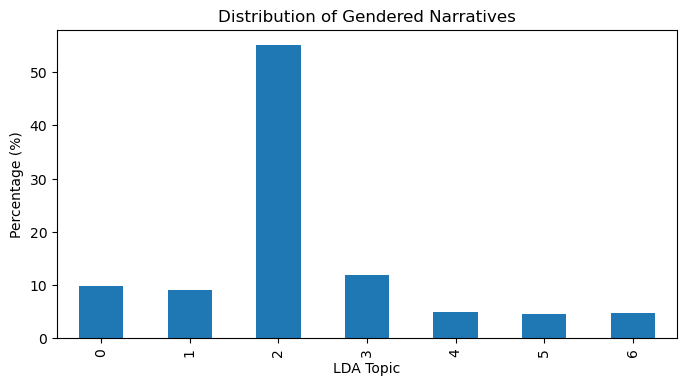

In [23]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))

ax = topic_percentage.plot(
    kind='bar')

plt.xlabel("LDA Topic")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Gendered Narratives")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',   # 保留1位小数 + %
        padding=3)

plt.tight_layout()
plt.show()

In [25]:
# 6. compare submission V.S. comment
type_topic_distribution = pd.crosstab(
    df_topic['source_type'],
    df_topic['lda_topic'],
    normalize='index'
)
type_topic_distribution

lda_topic,0,1,2,3,4,5,6
source_type,,,,,,,
comment,0.080311,0.080311,0.659585,0.100000,0.00829,0.036788,0.034715
submission,0.164557,0.130802,0.116034,0.191983,0.21519,0.082278,0.099156


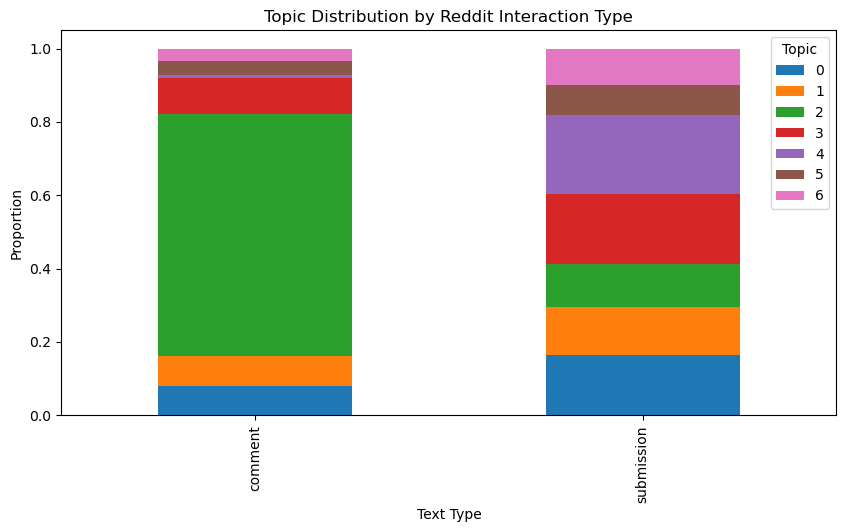

In [26]:
type_topic_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)


plt.xlabel(
    "Text Type"
)

plt.ylabel(
    "Proportion"
)

plt.title(
    "Topic Distribution by Reddit Interaction Type"
)

plt.legend(
    title="Topic"
)

plt.show()

In [4]:
df_topic = pd.read_csv(
    r"F:\ERP_data\LDA_topic_assigned.csv"
)
type_topic_distribution = pd.crosstab(
    df_topic['source_type'],
    df_topic['lda_topic'],
    normalize='index'
)
type_topic_distribution

lda_topic,0,1,2,3,4,5,6
source_type,,,,,,,
comment,0.079275,0.081347,0.661140,0.099482,0.00829,0.036788,0.033679
submission,0.164557,0.130802,0.116034,0.191983,0.21519,0.082278,0.099156


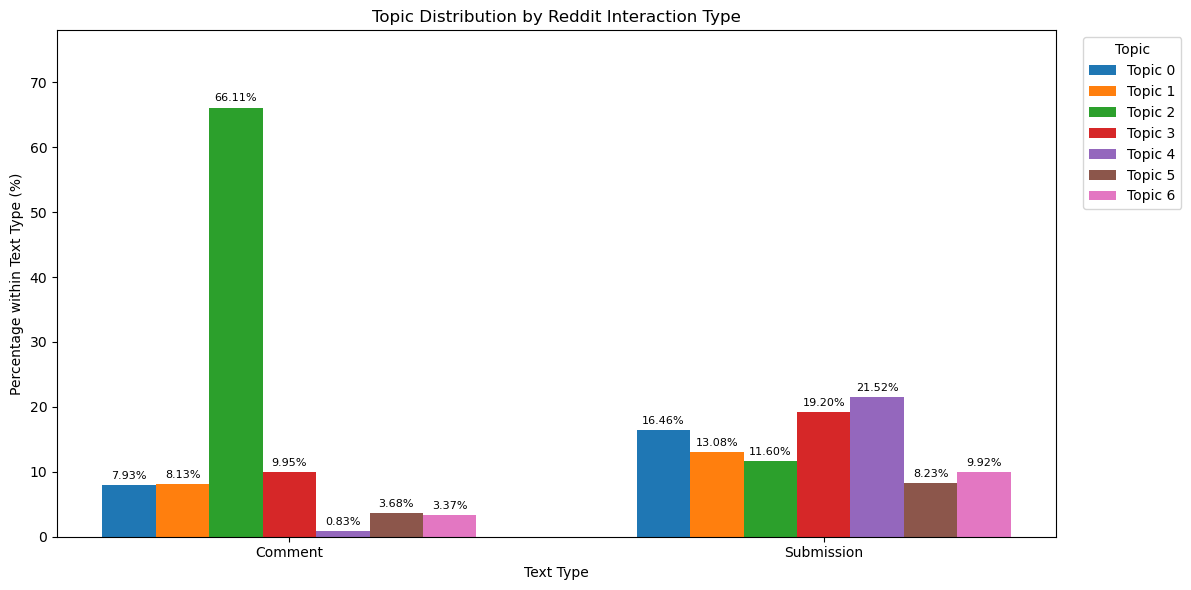

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

type_topic_distribution = pd.crosstab(
    df_topic['source_type'],
    df_topic['lda_topic'],
    normalize='index'
)

type_topic_distribution = type_topic_distribution.loc[
    ['comment', 'submission'],
    [0, 1, 2, 3, 4, 5, 6]
]

plot_data = type_topic_distribution * 100

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
n_topics = 7
bar_width = 0.10
group_centers = np.array([0, 1])
offsets = (
    np.arange(n_topics) - (n_topics - 1) / 2
) * bar_width


for topic in range(n_topics):
    values = plot_data[topic].values
    bars = ax.bar(
        group_centers + offsets[topic],
        values,
        width=bar_width,
        label=f"Topic {topic}"
    )
    ax.bar_label(
        bars,
        labels=[f"{v:.2f}%" for v in values],
        padding=3,
        fontsize=8,
        rotation=0
    )


ax.set_xticks(group_centers)
ax.set_xticklabels(["Comment", "Submission"])

ax.set_xlabel("Text Type")
ax.set_ylabel("Percentage within Text Type (%)")

ax.set_title(
    "Topic Distribution by Reddit Interaction Type"
)

ax.legend(
    title="Topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_ylim(
    0,
    plot_data.values.max() * 1.18
)

plt.tight_layout()
plt.show()

In [28]:
# significance test for sub and com
from scipy.stats import chi2_contingency


table = pd.crosstab(
    df_topic['source_type'],
    df_topic['lda_topic']
)


chi2, p, dof, expected = chi2_contingency(table)


print("Chi-square:", chi2)
print("p-value:", p)
# results: p<0.001

Chi-square: 651.8021471758362
p-value: 1.5515610064310664e-137


In [29]:
type_topic_distribution.round(3)

lda_topic,0,1,2,3,4,5,6
source_type,,,,,,,
comment,0.080,0.080,0.660,0.100,0.008,0.037,0.035
submission,0.165,0.131,0.116,0.192,0.215,0.082,0.099


In [35]:
# the effect size (size of the difference)
import numpy as np
from scipy.stats import chi2_contingency


table = pd.crosstab(
    df_topic['source_type'],
    df_topic['lda_topic']
)


chi2, p, dof, expected = chi2_contingency(table)


n = table.sum().sum()

phi2 = chi2 / n

r, k = table.shape

cramers_v = np.sqrt(
    phi2 / min(k-1, r-1)
)


print(cramers_v)  # result 0.52 > 0.5, large effect

0.5207036976586008


In [36]:
# 7. assign each text for the dominant topic
topic_results = []

for bow in corpus:

    topic_probabilities = lda_model.get_document_topics(bow)

    dominant_topic = max(
        topic_probabilities,
        key=lambda x:x[1]
    )

    topic_results.append(dominant_topic)


df_topic['lda_topic'] = [
    x[0] for x in topic_results
]


df_topic['topic_probability'] = [
    x[1] for x in topic_results
]

In [38]:
# save
df_topic.to_csv(
    r"F:\ERP_data\LDA_topic_assigned.csv",
    index=False,
    encoding="utf-8-sig"
)

In [39]:
lda_model.save(
    r"F:\ERP_data\lda_k7_model"
)

In [40]:
dictionary.save(
    r"F:\ERP_data\lda_dictionary"
)